# PACO VIP-fork (GPU) - Benchmark ALL datasets desde Drive

Version ALL datasets basada en la version funcional de referencia.

In [1]:
# Setup general (Drive-only, robusto)
import json
import time
import hashlib
import warnings
import subprocess
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy import ndimage
from IPython.display import display

warnings.filterwarnings("ignore")

RUN_LABEL = "gpu_all"
ENABLE_GPU = True
COUNTERPART_LABEL = "cpu_all"

# Dependencias
subprocess.check_call([
    "python3", "-m", "pip", "install", "-q",
    "astropy", "scipy", "matplotlib", "pandas", "numpy", "seaborn"
])

# Montar Drive en Colab (sin fallar si ya esta montado)
try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive", force_remount=False)
    else:
        print("[INFO] Drive ya disponible en /content/drive/MyDrive")
except Exception as exc:
    print(f"[INFO] Entorno no-Colab o Drive ya montado: {exc}")

# Resolver raiz de Drive y rutas automaticamente
DRIVE_ROOT = Path("/content/drive/MyDrive")
if not DRIVE_ROOT.exists():
    # Fallback para entornos fuera de Colab
    DRIVE_ROOT = Path.cwd()

vip_candidates = [
    DRIVE_ROOT / "VIP-master" / "VIP-master",
    DRIVE_ROOT / "tesis" / "VIP-master" / "VIP-master",
]
subchallenge_candidates = [
    DRIVE_ROOT / "subchallenge1",
    DRIVE_ROOT / "tesis" / "subchallenge1",
]

VIP_DIR = next((p for p in vip_candidates if p.exists()), None)
SUBCHALLENGE_DIR = next((p for p in subchallenge_candidates if p.exists()), None)

if VIP_DIR is None:
    raise RuntimeError(
        "No se encontro VIP-master en rutas candidatas. Ajusta VIP_DIR manualmente en esta celda.\n"
        + "\n".join([f"- {p}" for p in vip_candidates])
    )

if SUBCHALLENGE_DIR is None:
    raise RuntimeError(
        "No se encontro subchallenge1 en rutas candidatas. Ajusta SUBCHALLENGE_DIR manualmente en esta celda.\n"
        + "\n".join([f"- {p}" for p in subchallenge_candidates])
    )

OUTPUT_DIR = DRIVE_ROOT / "paco_benchmarks" / RUN_LABEL
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Instalar VIP-fork desde Drive
subprocess.run(["python3", "-m", "pip", "uninstall", "-y", "-q", "vip-hci"], check=False)
subprocess.check_call(["python3", "-m", "pip", "install", "-q", "-e", str(VIP_DIR)])

import sys
vip_src = VIP_DIR / "src"
if vip_src.exists() and str(vip_src) not in sys.path:
    sys.path.insert(0, str(vip_src))

import vip_hci as vip
from vip_hci.invprob import paco as paco_module
from vip_hci.invprob.paco import FastPACO

import importlib
import shutil

VIP_PACO_PATH = vip_src / "vip_hci" / "invprob" / "paco.py"
VIP_PACO_BACKUP_PATH = vip_src / "vip_hci" / "invprob" / "paco_vip_backup.py"

# Si CPU_ALL sobrescribio paco.py con el original, restaurar backup VIP
if not hasattr(paco_module, "enable_paco_gpu_backend"):
    backup_ok = False
    if VIP_PACO_BACKUP_PATH.exists():
        btxt = VIP_PACO_BACKUP_PATH.read_text(encoding="utf-8", errors="ignore")
        backup_ok = "enable_paco_gpu_backend" in btxt

    if backup_ok:
        shutil.copyfile(VIP_PACO_BACKUP_PATH, VIP_PACO_PATH)
        importlib.invalidate_caches()
        for mod in ["vip_hci.invprob.paco", "vip_hci.invprob"]:
            if mod in sys.modules:
                del sys.modules[mod]
        from vip_hci.invprob import paco as paco_module
        from vip_hci.invprob.paco import FastPACO
        print(f"[INFO] Restaurado PACO VIP desde backup: {VIP_PACO_BACKUP_PATH}")
    else:
        raise RuntimeError(
            "El modulo PACO cargado no tiene backend GPU y no hay backup VIP valido. "
            "Restaura un paco.py de VIP-fork con soporte GPU en VIP-master/src/vip_hci/invprob/paco.py."
        )

# Wrapper de compatibilidad (debe existir para GPU en VIP)
def _set_paco_backend(enable_gpu: bool):
    if hasattr(paco_module, "enable_paco_gpu_backend"):
        paco_module.enable_paco_gpu_backend(enable_gpu)
    else:
        raise RuntimeError("El modulo PACO activo no soporta backend GPU.")

GPU_AVAILABLE = False
GPU_NAME = "N/A"
try:
    import cupy as cp
    cp.zeros(1)
    GPU_AVAILABLE = True
    GPU_NAME = cp.cuda.runtime.getDeviceProperties(0)["name"].decode()
except Exception:
    pass

if ENABLE_GPU and not GPU_AVAILABLE:
    raise RuntimeError("Este notebook es GPU pero no detecta CuPy/GPU. Cambia runtime a GPU en Colab.")

_set_paco_backend(ENABLE_GPU)

print(f"RUN_LABEL      : {RUN_LABEL}")
print(f"ENABLE_GPU     : {ENABLE_GPU}")
print(f"GPU_AVAILABLE  : {GPU_AVAILABLE}")
print(f"GPU_NAME       : {GPU_NAME}")
print(f"VIP version    : {getattr(vip, '__version__', 'desconocida')}")
print(f"DRIVE_ROOT     : {DRIVE_ROOT}")
print(f"SUBCHALLENGE   : {SUBCHALLENGE_DIR}")
print(f"VIP_DIR        : {VIP_DIR}")
print(f"OUTPUT_DIR     : {OUTPUT_DIR}")

[INFO] Drive ya disponible en /content/drive/MyDrive
RUN_LABEL      : gpu_all
ENABLE_GPU     : True
GPU_AVAILABLE  : True
GPU_NAME       : Tesla T4
VIP version    : 2.0.0
DRIVE_ROOT     : /content/drive/MyDrive
SUBCHALLENGE   : /content/drive/MyDrive/subchallenge1
VIP_DIR        : /content/drive/MyDrive/VIP-master/VIP-master
OUTPUT_DIR     : /content/drive/MyDrive/paco_benchmarks/gpu_all


In [2]:
# Hiperparametros bloqueados para comparacion 1:1
LOCKED_HPARAMS = {
    "datasets": [
        "lmircam_1", "lmircam_2", "lmircam_3",
        "nirc2_1", "nirc2_2", "nirc2_3",
        "sphere_irdis_1", "sphere_irdis_2", "sphere_irdis_3",
    ],
    "frame_stride": 1,
    "crop_half_size": 75,
    "benchmark_pixels": 2500,
    "inner_radius": 8,
    "outer_radius": 55,
    "cpu_threads": 1,
    "use_subpixel_psf_astrometry": False,
    "warmup_gpu": True,
    "profile_dataset": "lmircam_1",
    "profile_pixels": 120,
    "snr_thresholds": [3, 5, 7],
}


RUN_MODE = "full"  # "full" o "quick"
if RUN_MODE == "quick":
    LOCKED_HPARAMS["frame_stride"] = 5
    LOCKED_HPARAMS["benchmark_pixels"] = 500
    LOCKED_HPARAMS["profile_pixels"] = 60

HP_FINGERPRINT = hashlib.sha256(
    json.dumps(LOCKED_HPARAMS, sort_keys=True).encode("utf-8")
).hexdigest()

print("LOCKED_HPARAMS:")
for k, v in LOCKED_HPARAMS.items():
    print(f"  - {k}: {v}")
print(f"HP_FINGERPRINT: {HP_FINGERPRINT}")

LOCKED_HPARAMS:
  - datasets: ['lmircam_1', 'lmircam_2', 'lmircam_3', 'nirc2_1', 'nirc2_2', 'nirc2_3', 'sphere_irdis_1', 'sphere_irdis_2', 'sphere_irdis_3']
  - frame_stride: 1
  - crop_half_size: 75
  - benchmark_pixels: 2500
  - inner_radius: 8
  - outer_radius: 55
  - cpu_threads: 1
  - use_subpixel_psf_astrometry: False
  - warmup_gpu: True
  - profile_dataset: lmircam_1
  - profile_pixels: 120
  - snr_thresholds: [3, 5, 7]
HP_FINGERPRINT: a8300ca1fa4e334233ffa749356252207e3c99cf62c92ebde80b2494c9596f85


In [3]:
# Funciones utilitarias

def parse_dataset_name(name):
    parts = name.split("_")
    return "_".join(parts[:-1]), int(parts[-1])


def load_dataset_from_drive(base_dir, dataset_name, frame_stride=1):
    instrument, dataset_id = parse_dataset_name(dataset_name)
    base = Path(base_dir)

    cube = fits.getdata(base / f"{instrument}_cube_{dataset_id}.fits")
    angles = fits.getdata(base / f"{instrument}_pa_{dataset_id}.fits").flatten()
    psf = fits.getdata(base / f"{instrument}_psf_{dataset_id}.fits")

    px_path = base / f"{instrument}_pxscale_{dataset_id}.fits"
    pixscale = float(fits.getdata(px_path).flatten()[0])

    # Recuperacion robusta cuando pxscale viene NaN/inf/<=0
    if (not np.isfinite(pixscale)) or (pixscale <= 0):
        candidates = []
        for p in sorted(base.glob(f"{instrument}_pxscale_*.fits")):
            try:
                v = float(fits.getdata(p).flatten()[0])
                if np.isfinite(v) and v > 0:
                    candidates.append(v)
            except Exception:
                continue
        if candidates:
            pixscale = float(np.median(candidates))
            print(f"[WARNING] pixscale invalido en {px_path.name}; usando mediana {pixscale:.6f} del instrumento {instrument}")
        else:
            fallback = {
                "lmircam": 0.02014,
                "nirc2": 0.00995,
                "sphere_irdis": 0.01225,
            }
            pixscale = float(fallback.get(instrument, 0.01))
            print(f"[WARNING] No hay pxscale valido para {instrument}; usando fallback {pixscale:.6f}")

    if int(frame_stride) > 1:
        cube = cube[::frame_stride]
        angles = angles[::frame_stride]

    return cube, angles, psf, pixscale


def crop_cube_center(cube, half_size=75):
    if cube.shape[1] <= (2 * half_size) or cube.shape[2] <= (2 * half_size):
        return cube
    cy, cx = cube.shape[1] // 2, cube.shape[2] // 2
    return cube[:, cy-half_size:cy+half_size, cx-half_size:cx+half_size]


def build_phi0_annulus(img_shape, n_pixels_target=2500, inner_radius=8, outer_radius=55):
    h, w = int(img_shape[0]), int(img_shape[1])
    cy, cx = h // 2, w // 2
    outer_eff = min(outer_radius, min(cy, cx) - 5)

    yy, xx = np.indices((h, w))
    rr = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)
    mask = (rr >= inner_radius) & (rr <= outer_eff)
    coords = np.column_stack((xx[mask], yy[mask]))

    if len(coords) == 0:
        raise RuntimeError("No se pudieron generar phi0s en el anillo")

    n_sel = min(int(n_pixels_target), len(coords))
    idx = np.linspace(0, len(coords) - 1, n_sel, dtype=int)
    return coords[idx].astype(np.int32), int(outer_eff)


def run_fastpaco_locked(cube, angles, psf, pixscale, phi0s, enable_gpu, cpu=1,
                        use_subpixel_psf_astrometry=False, warmup_gpu=True):
    _set_paco_backend(enable_gpu)

    gpu_sync = None
    if enable_gpu:
        try:
            import cupy as cp
            gpu_sync = cp.cuda.Stream.null.synchronize
        except Exception:
            gpu_sync = None

    fwhm_arcsec = 4.0 * pixscale
    model = FastPACO(
        cube=cube,
        angles=angles,
        psf=psf,
        fwhm=fwhm_arcsec,
        pixscale=pixscale,
        verbose=False,
    )

    if warmup_gpu and enable_gpu and gpu_sync is not None and len(phi0s) >= 32:
        _ = model.PACOCalc(phi0s[:32], use_subpixel_psf_astrometry=use_subpixel_psf_astrometry, cpu=cpu)
        gpu_sync()

    if gpu_sync is not None:
        gpu_sync()

    t0 = time.perf_counter()
    a, b = model.PACOCalc(phi0s, use_subpixel_psf_astrometry=use_subpixel_psf_astrometry, cpu=cpu)
    if gpu_sync is not None:
        gpu_sync()
    elapsed = time.perf_counter() - t0

    with np.errstate(divide="ignore", invalid="ignore"):
        snr = np.divide(b, np.sqrt(a), out=np.zeros_like(b), where=(a > 0))
        snr = np.nan_to_num(snr, nan=0.0, posinf=0.0, neginf=0.0)

    return {
        "time_s": float(elapsed),
        "a": a,
        "b": b,
        "snr": snr,
        "snr_max": float(np.nanmax(snr)),
        "snr_mean": float(np.nanmean(snr)),
        "snr_std": float(np.nanstd(snr)),
        "count_snr_gt_3": int(np.sum(snr > 3.0)),
        "count_snr_gt_5": int(np.sum(snr > 5.0)),
        "count_snr_gt_7": int(np.sum(snr > 7.0)),
    }


def snr_map_from_phi0s(snr, phi0s, image_shape):
    h, w = int(image_shape[0]), int(image_shape[1])
    out = np.full((h, w), np.nan, dtype=float)
    out[phi0s[:, 1], phi0s[:, 0]] = snr
    return out


def detection_stats_from_map(snr_map, thresholds=(3, 5, 7)):
    stats = {}
    for th in thresholds:
        binary = np.where(np.nan_to_num(snr_map, nan=-999) > th, 1, 0)
        labeled, n_lbl = ndimage.label(binary)
        if n_lbl == 0:
            stats[th] = {"count": 0, "max_blob_snr": 0.0}
            continue
        max_vals = []
        for lbl in range(1, n_lbl + 1):
            vals = snr_map[labeled == lbl]
            if vals.size:
                max_vals.append(float(np.nanmax(vals)))
        stats[th] = {
            "count": int(n_lbl),
            "max_blob_snr": float(max(max_vals)) if max_vals else 0.0,
        }
    return stats

In [4]:
# Benchmark principal (mismos hiperparametros en CPU/GPU)
assert SUBCHALLENGE_DIR.exists(), f"No existe SUBCHALLENGE_DIR: {SUBCHALLENGE_DIR}"

results_by_dataset = {}
rows = []

for ds_name in LOCKED_HPARAMS["datasets"]:
    print("\n" + "=" * 80)
    print(f"Procesando {ds_name} | backend={RUN_LABEL.upper()}")
    print("=" * 80)

    cube_raw, angles_raw, psf, pixscale = load_dataset_from_drive(
        SUBCHALLENGE_DIR,
        ds_name,
        frame_stride=LOCKED_HPARAMS["frame_stride"],
    )

    cube = crop_cube_center(cube_raw, LOCKED_HPARAMS["crop_half_size"])
    angles = angles_raw

    phi0s, outer_eff = build_phi0_annulus(
        img_shape=(cube.shape[1], cube.shape[2]),
        n_pixels_target=LOCKED_HPARAMS["benchmark_pixels"],
        inner_radius=LOCKED_HPARAMS["inner_radius"],
        outer_radius=LOCKED_HPARAMS["outer_radius"],
    )

    res = run_fastpaco_locked(
        cube=cube,
        angles=angles,
        psf=psf,
        pixscale=pixscale,
        phi0s=phi0s,
        enable_gpu=ENABLE_GPU,
        cpu=LOCKED_HPARAMS["cpu_threads"],
        use_subpixel_psf_astrometry=LOCKED_HPARAMS["use_subpixel_psf_astrometry"],
        warmup_gpu=LOCKED_HPARAMS["warmup_gpu"],
    )

    snr_map = snr_map_from_phi0s(res["snr"], phi0s, (cube.shape[1], cube.shape[2]))
    det_stats = detection_stats_from_map(snr_map, thresholds=tuple(LOCKED_HPARAMS["snr_thresholds"]))

    payload = {
        "dataset": ds_name,
        "cube_shape": tuple(cube.shape),
        "angles_len": int(len(angles)),
        "psf_shape": tuple(psf.shape),
        "pixscale": float(pixscale),
        "fwhm_arcsec": float(4.0 * pixscale),
        "phi0s": phi0s,
        "outer_radius_eff": int(outer_eff),
        "snr_map": snr_map,
        "detections": det_stats,
        **res,
    }
    results_by_dataset[ds_name] = payload

    rows.append({
        "Backend": RUN_LABEL.upper(),
        "Dataset": ds_name,
        "Tiempo (s)": res["time_s"],
        "Pixeles": len(phi0s),
        "Frames": cube.shape[0],
        "SNR max": res["snr_max"],
        "SNR mean": res["snr_mean"],
        "SNR std": res["snr_std"],
        "SNR>3": res["count_snr_gt_3"],
        "SNR>5": res["count_snr_gt_5"],
        "SNR>7": res["count_snr_gt_7"],
        "Blobs>3": det_stats[3]["count"],
        "Blobs>5": det_stats[5]["count"],
        "Blobs>7": det_stats[7]["count"],
    })

    print(f"[OK] {ds_name}: tiempo={res['time_s']:.2f}s | SNR max={res['snr_max']:.2f} | SNR mean={res['snr_mean']:.4f}")

benchmark_df = pd.DataFrame(rows)
display(benchmark_df)

print("\nResumen tiempos:")
print(benchmark_df[["Dataset", "Tiempo (s)", "Pixeles", "Frames"]].to_string(index=False))


Procesando lmircam_1 | backend=GPU_ALL
[OK] lmircam_1: tiempo=153.55s | SNR max=18.18 | SNR mean=0.0786

Procesando lmircam_2 | backend=GPU_ALL
[OK] lmircam_2: tiempo=102.41s | SNR max=16.72 | SNR mean=0.0280

Procesando lmircam_3 | backend=GPU_ALL
[OK] lmircam_3: tiempo=145.67s | SNR max=13.99 | SNR mean=-0.0259

Procesando nirc2_1 | backend=GPU_ALL
[WARNING] No hay pxscale valido para nirc2; usando fallback 0.009950
[OK] nirc2_1: tiempo=2.12s | SNR max=2.05 | SNR mean=0.0368

Procesando nirc2_2 | backend=GPU_ALL
[WARNING] No hay pxscale valido para nirc2; usando fallback 0.009950
[OK] nirc2_2: tiempo=1.69s | SNR max=3.04 | SNR mean=-0.0121

Procesando nirc2_3 | backend=GPU_ALL
[WARNING] No hay pxscale valido para nirc2; usando fallback 0.009950
[OK] nirc2_3: tiempo=1.97s | SNR max=2.61 | SNR mean=0.0034

Procesando sphere_irdis_1 | backend=GPU_ALL
[OK] sphere_irdis_1: tiempo=8.03s | SNR max=4.14 | SNR mean=0.0220

Procesando sphere_irdis_2 | backend=GPU_ALL
[OK] sphere_irdis_2: tiem

,Backend,Dataset,Tiempo (s),Pixeles,Frames,SNR max,SNR mean,SNR std,SNR>3,SNR>5,SNR>7,Blobs>3,Blobs>5,Blobs>7
0,GPU_ALL,lmircam_1,153.548293,2500,4838,18.183560,0.078587,4.320611,619,316,146,517,277,136
1,GPU_ALL,lmircam_2,102.407917,2500,3219,16.724239,0.028005,4.362098,614,290,133,550,264,123
2,GPU_ALL,lmircam_3,145.670178,2500,4620,13.992628,-0.025937,5.250715,757,487,236,648,427,213
3,GPU_ALL,nirc2_1,2.120595,2500,29,2.053452,0.036764,0.530948,0,0,0,0,0,0
4,GPU_ALL,nirc2_2,1.694644,2500,40,3.037016,-0.012076,0.731256,1,0,0,1,0,0
5,GPU_ALL,nirc2_3,1.967081,2500,50,2.614047,0.003367,0.762275,0,0,0,0,0,0
6,GPU_ALL,sphere_irdis_1,8.026467,2500,252,4.143901,0.022014,1.164224,19,0,0,19,0,0
7,GPU_ALL,sphere_irdis_2,2.844208,2500,80,3.441927,-0.004812,0.891179,3,0,0,3,0,0
8,GPU_ALL,sphere_irdis_3,7.588221,2500,228,12.044043,0.013605,1.144229,25,5,3,23,5,3



Resumen tiempos:
       Dataset  Tiempo (s)  Pixeles  Frames
     lmircam_1  153.548293     2500    4838
     lmircam_2  102.407917     2500    3219
     lmircam_3  145.670178     2500    4620
       nirc2_1    2.120595     2500      29
       nirc2_2    1.694644     2500      40
       nirc2_3    1.967081     2500      50
sphere_irdis_1    8.026467     2500     252
sphere_irdis_2    2.844208     2500      80
sphere_irdis_3    7.588221     2500     228


In [5]:
# Perfilado (cProfile) para identificar cuellos de botella
import cProfile
import pstats

profile_ds = LOCKED_HPARAMS["profile_dataset"]
if profile_ds not in results_by_dataset:
    profile_ds = list(results_by_dataset.keys())[0]

instrument, dataset_id = parse_dataset_name(profile_ds)
cube_raw, angles_raw, psf, pixscale = load_dataset_from_drive(
    SUBCHALLENGE_DIR,
    profile_ds,
    frame_stride=LOCKED_HPARAMS["frame_stride"],
)
cube = crop_cube_center(cube_raw, LOCKED_HPARAMS["crop_half_size"])
phi0s_all, _ = build_phi0_annulus(
    img_shape=(cube.shape[1], cube.shape[2]),
    n_pixels_target=LOCKED_HPARAMS["benchmark_pixels"],
    inner_radius=LOCKED_HPARAMS["inner_radius"],
    outer_radius=LOCKED_HPARAMS["outer_radius"],
)
phi0s_prof = phi0s_all[:LOCKED_HPARAMS["profile_pixels"]]

_set_paco_backend(ENABLE_GPU)
model = FastPACO(cube=cube, angles=angles_raw, psf=psf, fwhm=4.0*pixscale, pixscale=pixscale, verbose=False)

prof = cProfile.Profile()
prof.enable()
a_prof, b_prof = model.PACOCalc(
    phi0s_prof,
    use_subpixel_psf_astrometry=LOCKED_HPARAMS["use_subpixel_psf_astrometry"],
    cpu=LOCKED_HPARAMS["cpu_threads"],
)
prof.disable()

stats = pstats.Stats(prof).sort_stats("cumulative")
stats_path = OUTPUT_DIR / f"cprofile_top_{RUN_LABEL}.txt"
stats.dump_stats(str(OUTPUT_DIR / f"cprofile_raw_{RUN_LABEL}.prof"))

# Guardar top funciones
import io
s = io.StringIO()
pstats.Stats(prof, stream=s).sort_stats("cumulative").print_stats(40)
with open(stats_path, "w") as f:
    f.write(s.getvalue())

# Tabla resumida filtrada a funciones PACO
profile_rows = []
for func, stat in stats.stats.items():
    cc, nc, tt, ct, callers = stat
    file_path, line_no, func_name = func
    if "paco" in file_path.lower() or "PACO" in func_name:
        profile_rows.append({
            "func": f"{Path(file_path).name}:{line_no}({func_name})",
            "ncalls": nc,
            "tottime_s": tt,
            "cumtime_s": ct,
        })

profile_df = pd.DataFrame(profile_rows).sort_values("cumtime_s", ascending=False).head(25)
if len(profile_df):
    display(profile_df)
else:
    print("[INFO] No se filtraron funciones PACO; revisa cprofile_top_*.txt")

print(f"[OK] Perfilado guardado en: {stats_path}")

,func,ncalls,tottime_s,cumtime_s
3,paco.py:948(compute_statistics),1,0.144223,1.318871
5,paco.py:1043(PACOCalc),1,0.316836,1.102526
1,paco.py:419(get_patch),120,0.929369,0.929951
0,paco.py:1501(_compute_statistics_batch_gpu),8,0.068376,0.130164
2,paco.py:1697(get_rotated_pixel_coords),120,0.006668,0.083205
4,paco.py:96(_resolve_gpu_batch_size),2,0.000032,0.000235
6,paco.py:1747(create_boolean_circular_mask),1,0.000040,0.000116


[OK] Perfilado guardado en: /content/drive/MyDrive/paco_benchmarks/gpu_all/cprofile_top_gpu_all.txt


In [6]:
# Validacion de consistencia de hiperparametros y salidas + metricas extra por corrida
validation_rows = []

for ds_name, res in results_by_dataset.items():
    validation_rows.append({
        "Dataset": ds_name,
        "Backend": RUN_LABEL.upper(),
        "HP fingerprint": HP_FINGERPRINT[:12],
        "frame_stride": LOCKED_HPARAMS["frame_stride"],
        "crop_half_size": LOCKED_HPARAMS["crop_half_size"],
        "benchmark_pixels": LOCKED_HPARAMS["benchmark_pixels"],
        "inner_radius": LOCKED_HPARAMS["inner_radius"],
        "outer_radius_req": LOCKED_HPARAMS["outer_radius"],
        "outer_radius_eff": res["outer_radius_eff"],
        "cpu_threads": LOCKED_HPARAMS["cpu_threads"],
        "use_subpixel": LOCKED_HPARAMS["use_subpixel_psf_astrometry"],
        "n_phi0s": len(res["phi0s"]),
        "angles_len": res["angles_len"],
        "cube_shape": str(res["cube_shape"]),
        "param_lock_ok": "OK",
    })

validation_df = pd.DataFrame(validation_rows)
display(validation_df)

assert all(validation_df["param_lock_ok"] == "OK"), "Fallo en lock de hiperparametros"
print("[OK] Validacion de hiperparametros completada")

# Metricas extra por corrida (diagnostico standalone CPU/GPU)
extra_metrics_df = benchmark_df.copy()
extra_metrics_df["Instrumento"] = extra_metrics_df["Dataset"].apply(lambda x: "_".join(str(x).split("_")[:-1]))
extra_metrics_df["Pixeles/s"] = extra_metrics_df["Pixeles"] / extra_metrics_df["Tiempo (s)"].clip(lower=1e-9)
extra_metrics_df["Frames*Pixeles/s"] = (extra_metrics_df["Frames"] * extra_metrics_df["Pixeles"]) / extra_metrics_df["Tiempo (s)"].clip(lower=1e-9)
extra_metrics_df["Frac SNR>3"] = extra_metrics_df["SNR>3"] / extra_metrics_df["Pixeles"].clip(lower=1)
extra_metrics_df["Frac SNR>5"] = extra_metrics_df["SNR>5"] / extra_metrics_df["Pixeles"].clip(lower=1)
extra_metrics_df["Frac SNR>7"] = extra_metrics_df["SNR>7"] / extra_metrics_df["Pixeles"].clip(lower=1)

instrument_metrics_df = extra_metrics_df.groupby("Instrumento", as_index=False).agg({
    "Dataset": "count",
    "Tiempo (s)": "sum",
    "Pixeles/s": "mean",
    "Frames*Pixeles/s": "mean",
    "SNR max": "mean",
    "SNR mean": "mean",
    "Frac SNR>5": "mean",
}).rename(columns={"Dataset": "n_datasets"})

global_metrics_df = pd.DataFrame([{
    "backend": RUN_LABEL.upper(),
    "n_datasets": int(len(extra_metrics_df)),
    "tiempo_total_s": float(extra_metrics_df["Tiempo (s)"].sum()),
    "tiempo_mediano_s": float(extra_metrics_df["Tiempo (s)"].median()),
    "pixeles_por_s_promedio": float(extra_metrics_df["Pixeles/s"].mean()),
    "snr_max_promedio": float(extra_metrics_df["SNR max"].mean()),
    "snr_mean_promedio": float(extra_metrics_df["SNR mean"].mean()),
}])

display(global_metrics_df)
display(instrument_metrics_df)
print("[OK] Metricas extra de corrida calculadas")

,Dataset,Backend,HP fingerprint,frame_stride,crop_half_size,benchmark_pixels,inner_radius,outer_radius_req,outer_radius_eff,cpu_threads,use_subpixel,n_phi0s,angles_len,cube_shape,param_lock_ok
0,lmircam_1,GPU_ALL,a8300ca1fa4e,1,75,2500,8,55,55,1,False,2500,4838,"(4838, 150, 150)",OK
1,lmircam_2,GPU_ALL,a8300ca1fa4e,1,75,2500,8,55,55,1,False,2500,3219,"(3219, 150, 150)",OK
2,lmircam_3,GPU_ALL,a8300ca1fa4e,1,75,2500,8,55,55,1,False,2500,4620,"(4620, 150, 150)",OK
3,nirc2_1,GPU_ALL,a8300ca1fa4e,1,75,2500,8,55,55,1,False,2500,29,"(29, 150, 150)",OK
4,nirc2_2,GPU_ALL,a8300ca1fa4e,1,75,2500,8,55,55,1,False,2500,40,"(40, 150, 150)",OK
5,nirc2_3,GPU_ALL,a8300ca1fa4e,1,75,2500,8,55,55,1,False,2500,50,"(50, 150, 150)",OK
6,sphere_irdis_1,GPU_ALL,a8300ca1fa4e,1,75,2500,8,55,55,1,False,2500,252,"(252, 150, 150)",OK
7,sphere_irdis_2,GPU_ALL,a8300ca1fa4e,1,75,2500,8,55,55,1,False,2500,80,"(80, 150, 150)",OK
8,sphere_irdis_3,GPU_ALL,a8300ca1fa4e,1,75,2500,8,55,55,1,False,2500,228,"(228, 150, 150)",OK


[OK] Validacion de hiperparametros completada


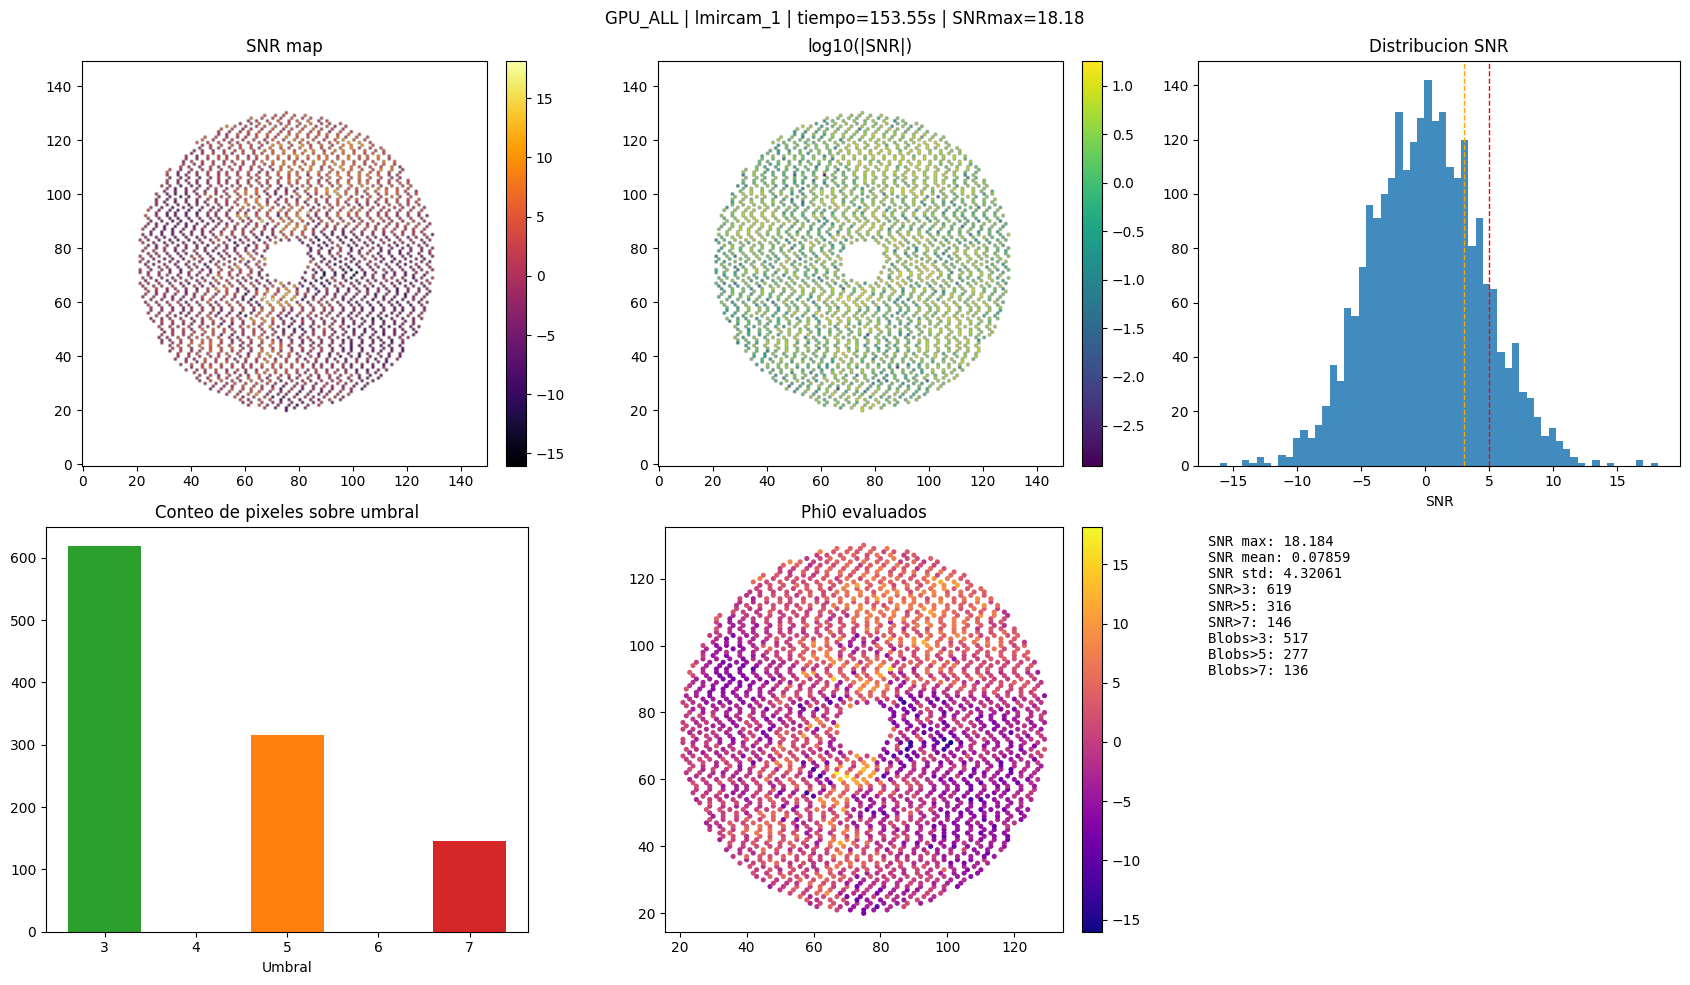

[OK] Figura guardada: /content/drive/MyDrive/paco_benchmarks/gpu_all/fig_gpu_all_lmircam_1.png


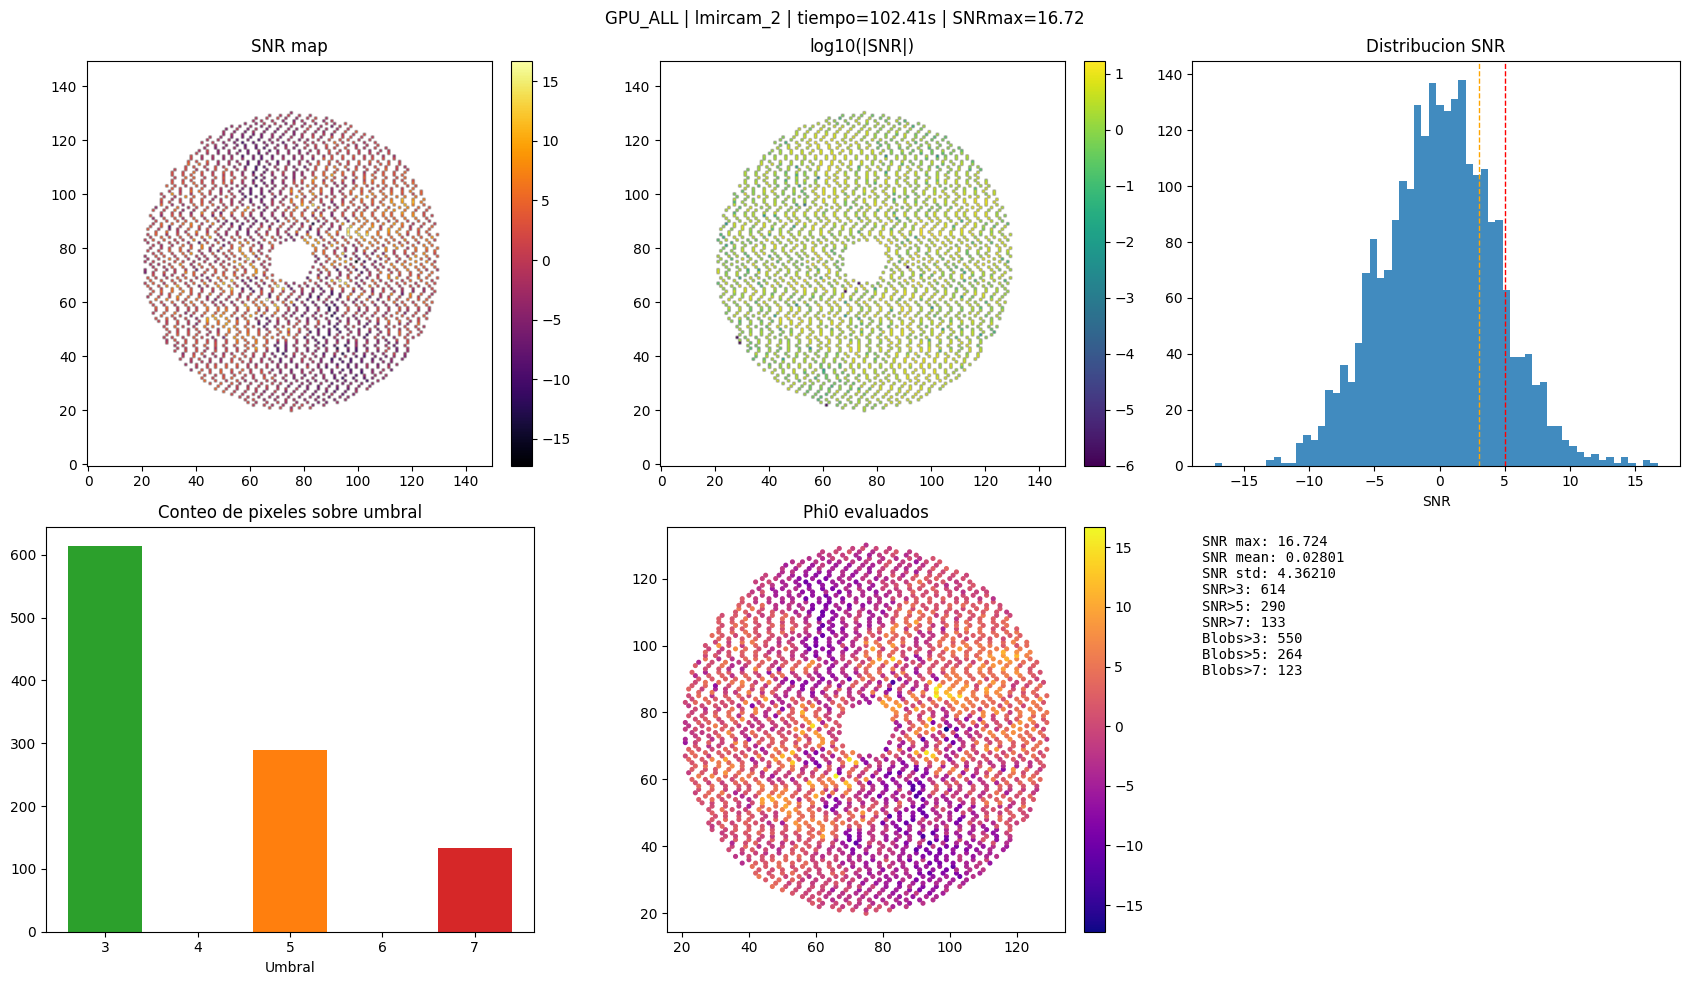

[OK] Figura guardada: /content/drive/MyDrive/paco_benchmarks/gpu_all/fig_gpu_all_lmircam_2.png


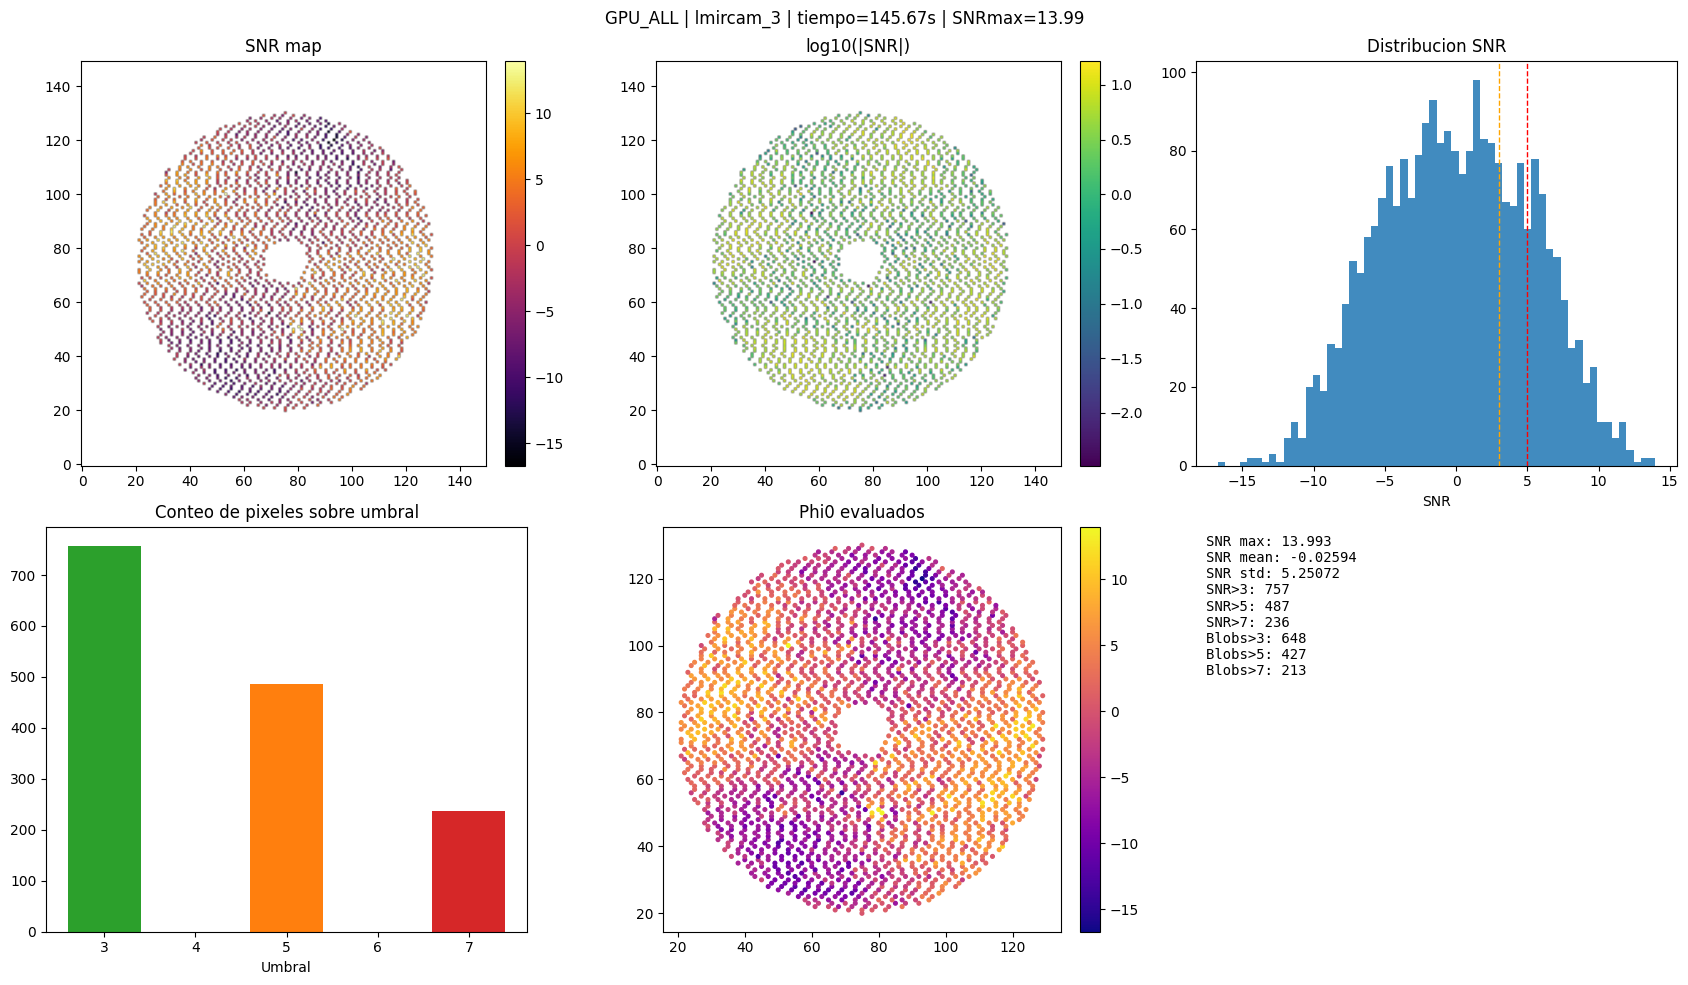

[OK] Figura guardada: /content/drive/MyDrive/paco_benchmarks/gpu_all/fig_gpu_all_lmircam_3.png


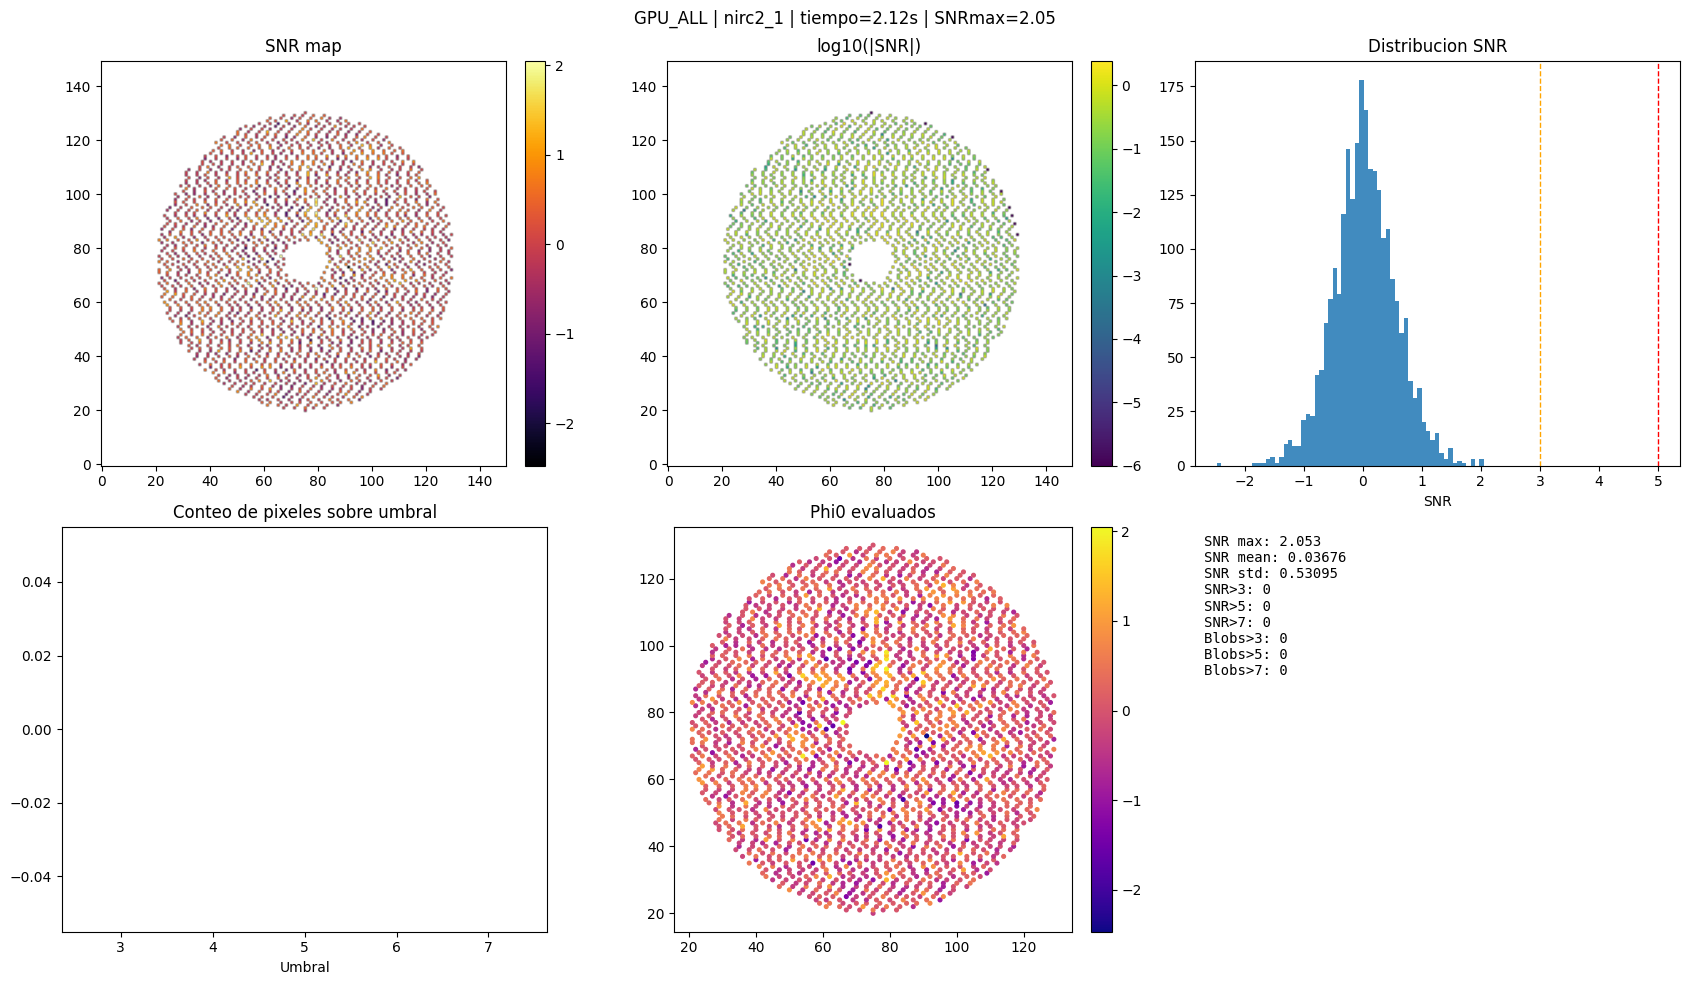

[OK] Figura guardada: /content/drive/MyDrive/paco_benchmarks/gpu_all/fig_gpu_all_nirc2_1.png


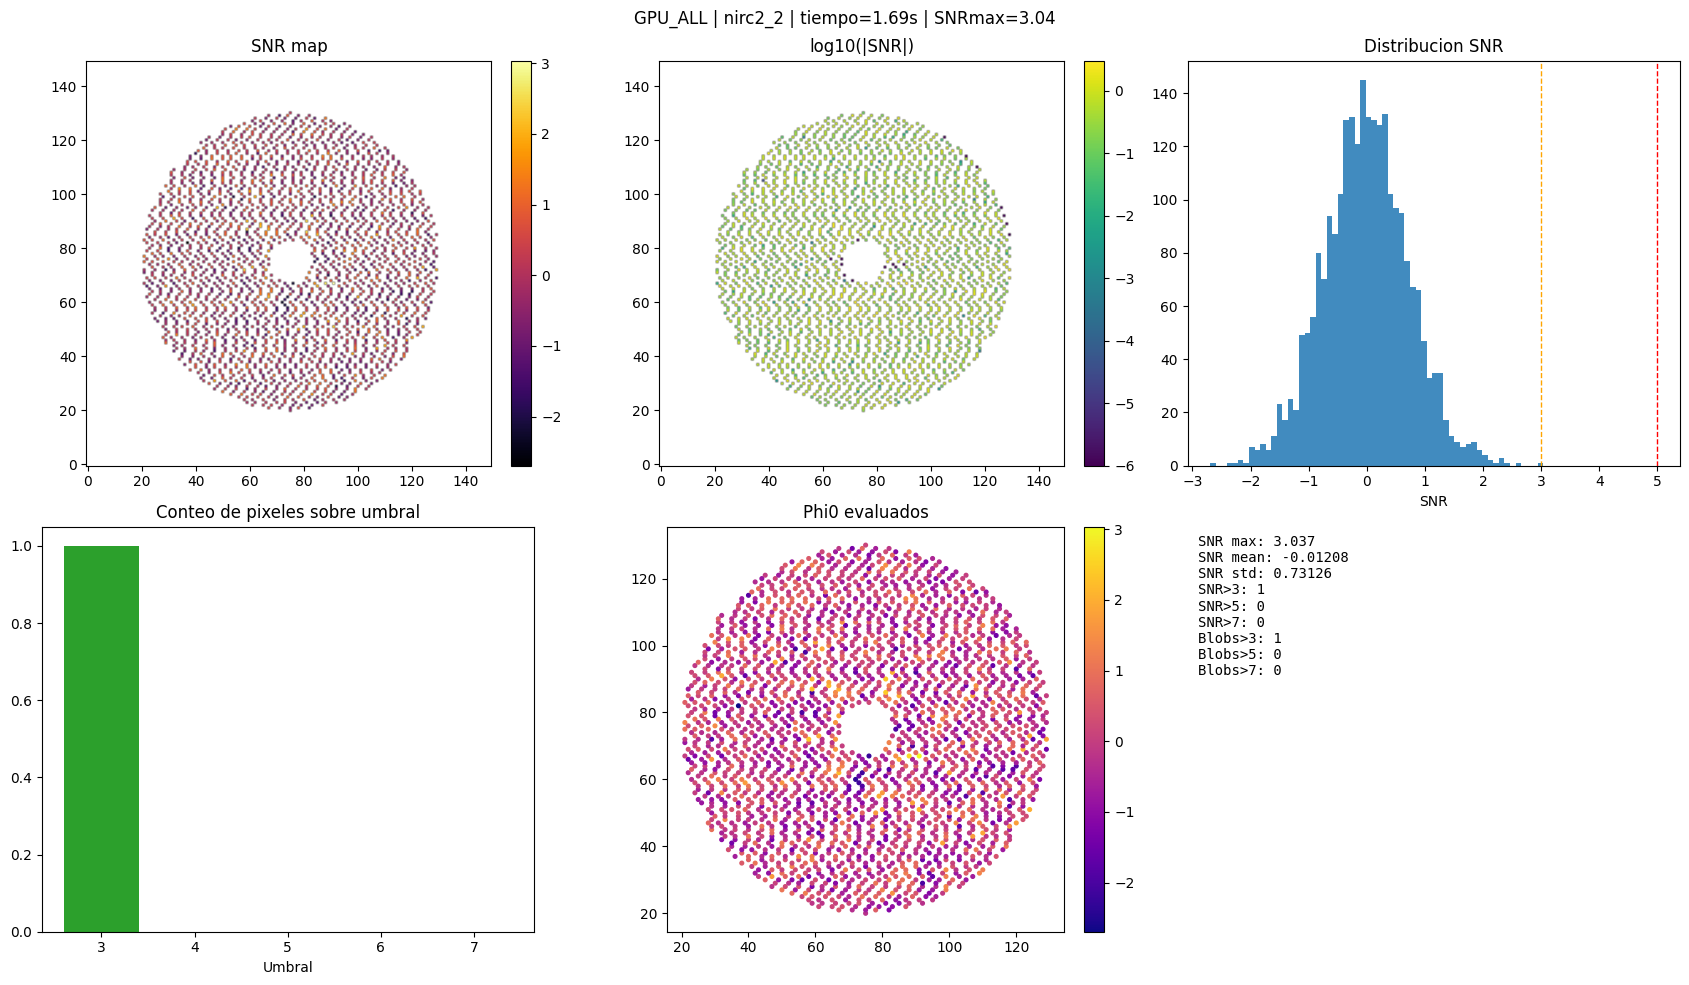

[OK] Figura guardada: /content/drive/MyDrive/paco_benchmarks/gpu_all/fig_gpu_all_nirc2_2.png


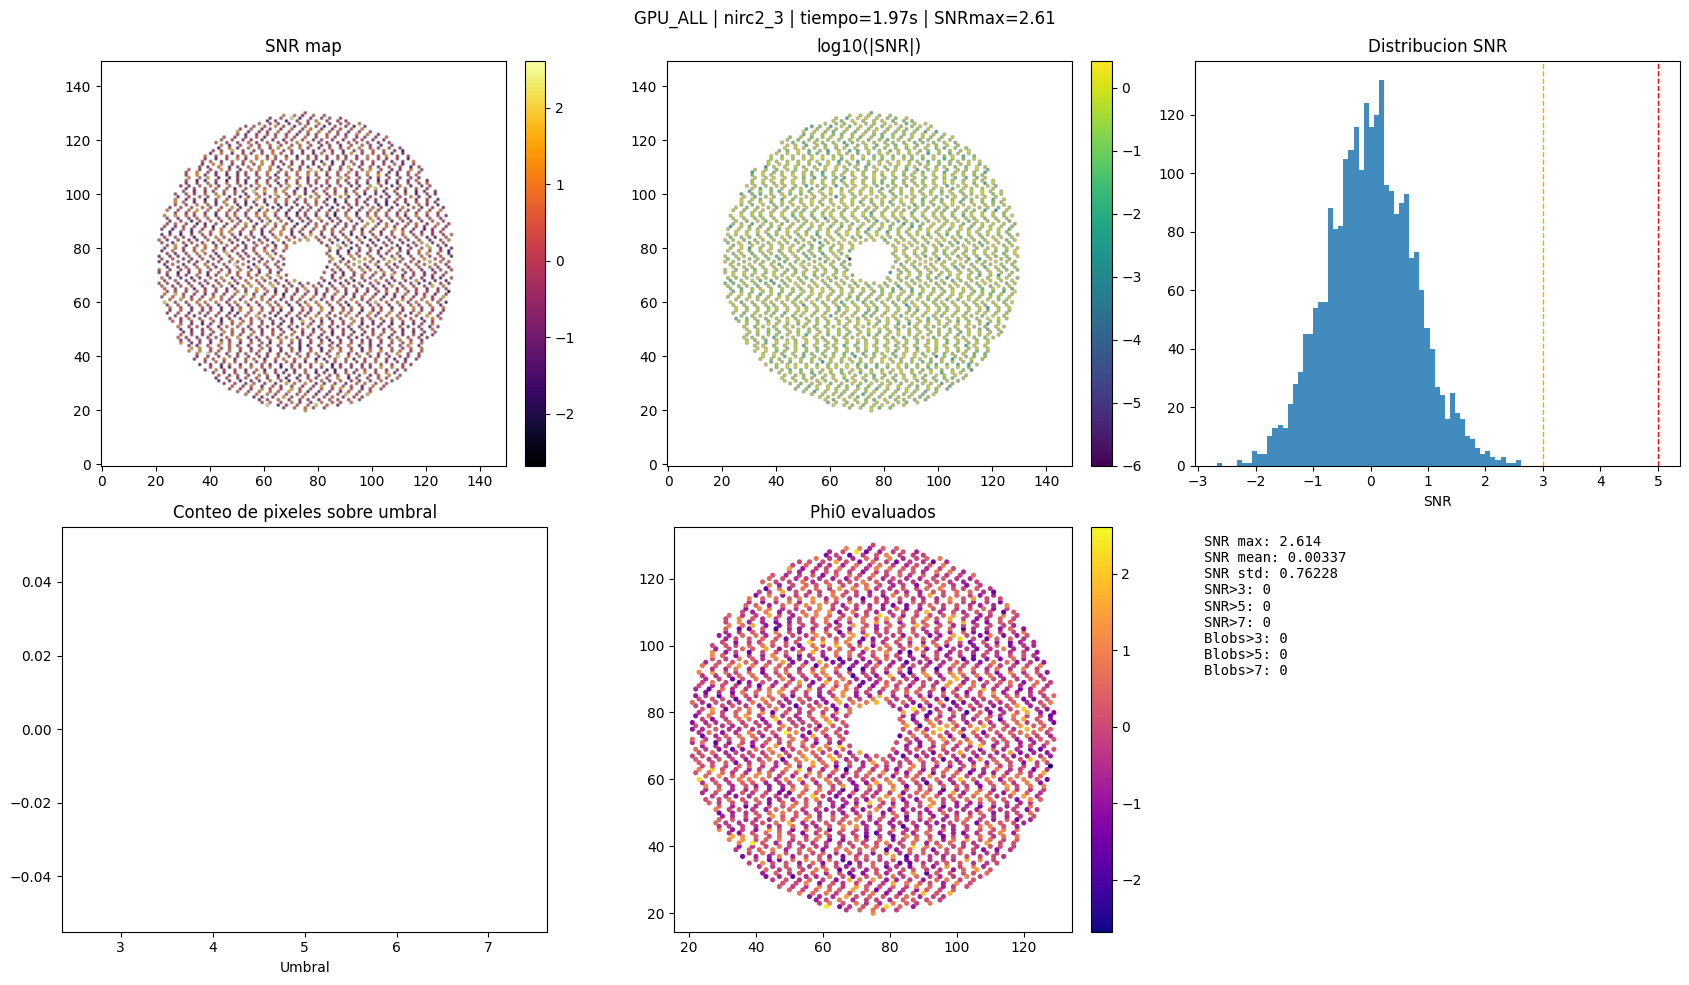

[OK] Figura guardada: /content/drive/MyDrive/paco_benchmarks/gpu_all/fig_gpu_all_nirc2_3.png


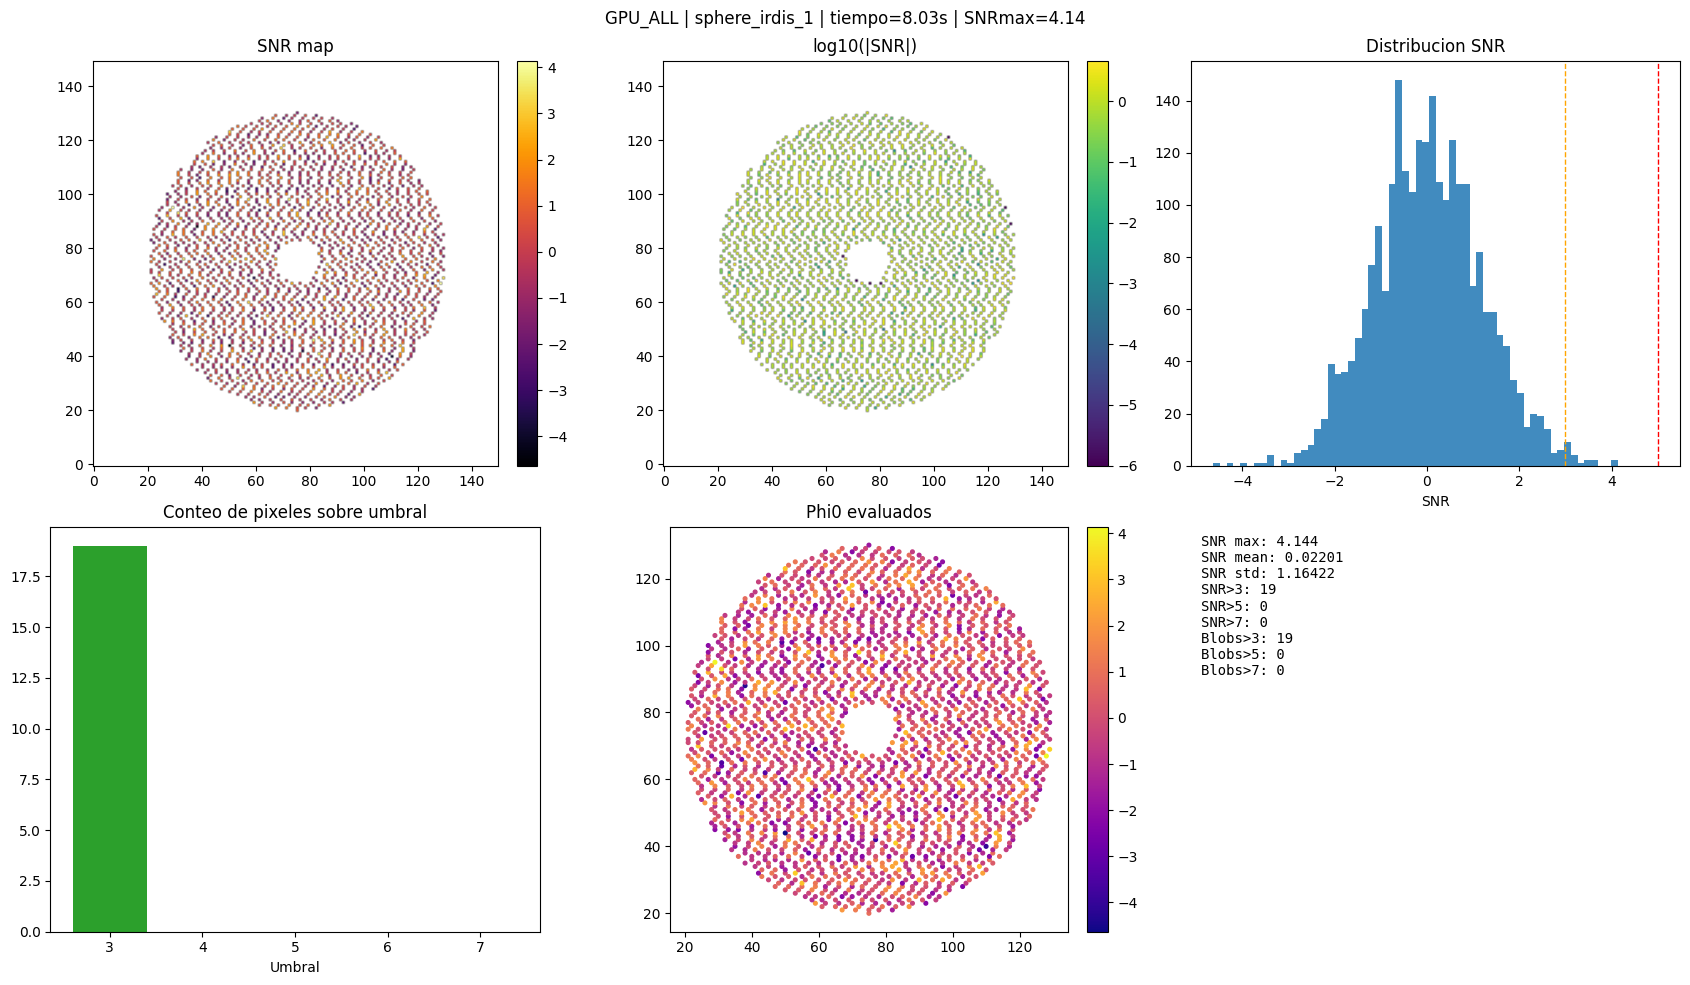

[OK] Figura guardada: /content/drive/MyDrive/paco_benchmarks/gpu_all/fig_gpu_all_sphere_irdis_1.png


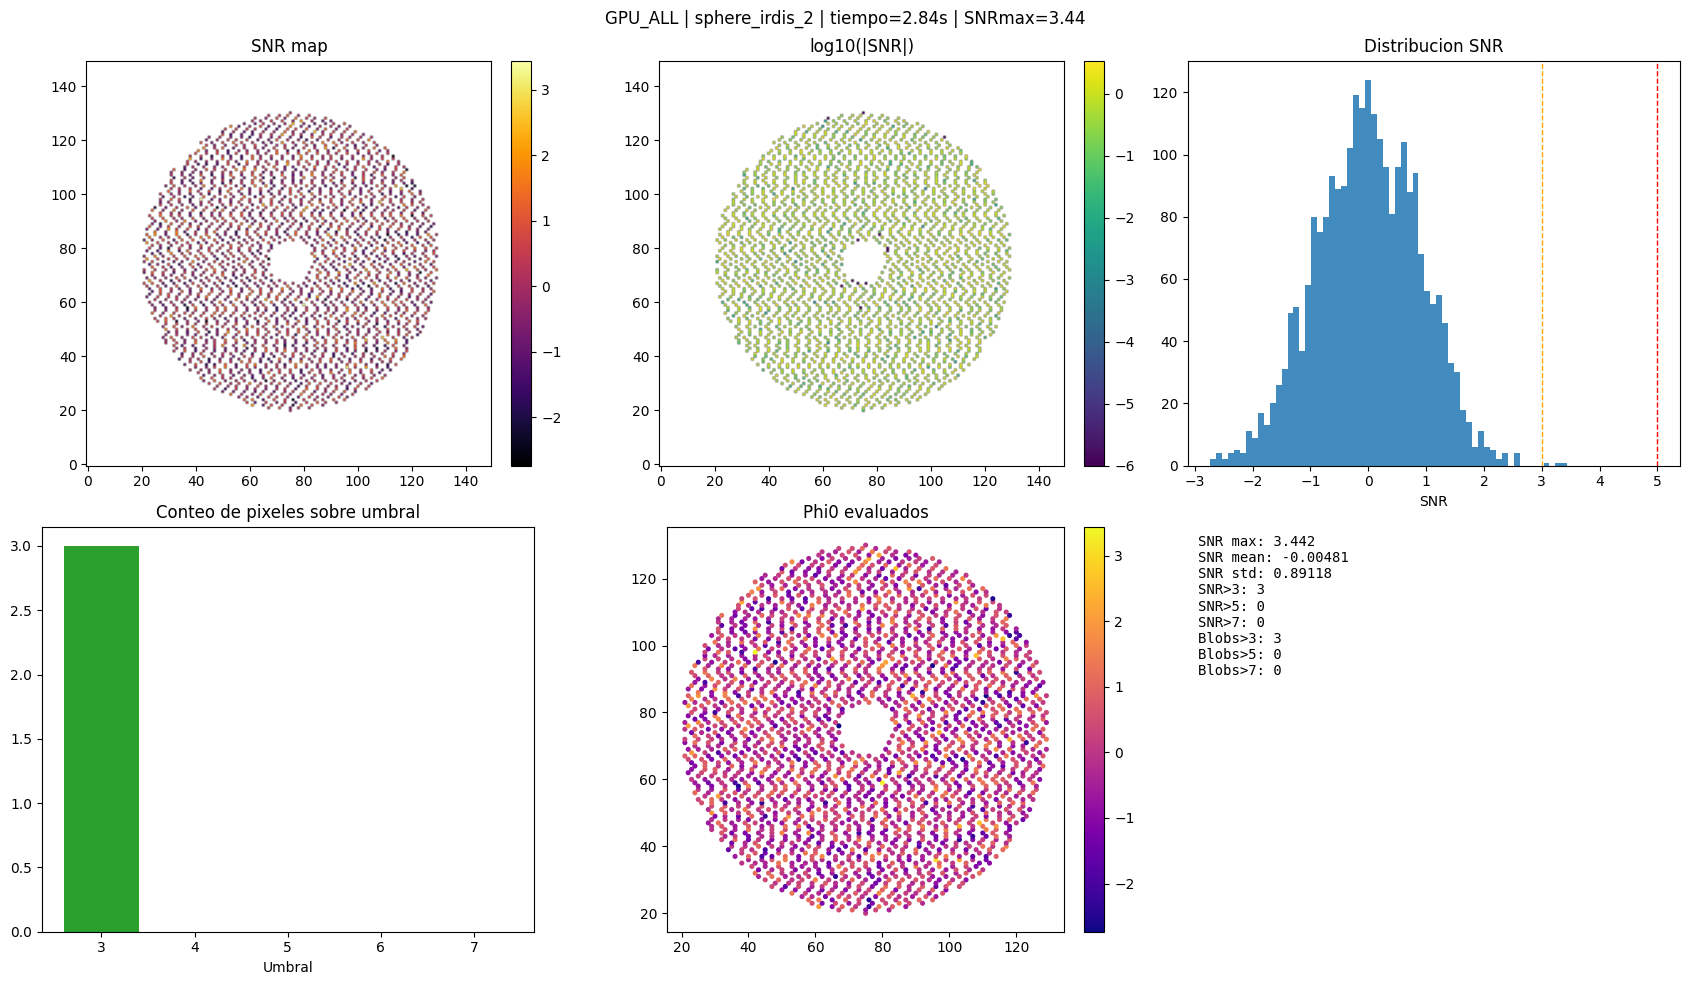

[OK] Figura guardada: /content/drive/MyDrive/paco_benchmarks/gpu_all/fig_gpu_all_sphere_irdis_2.png


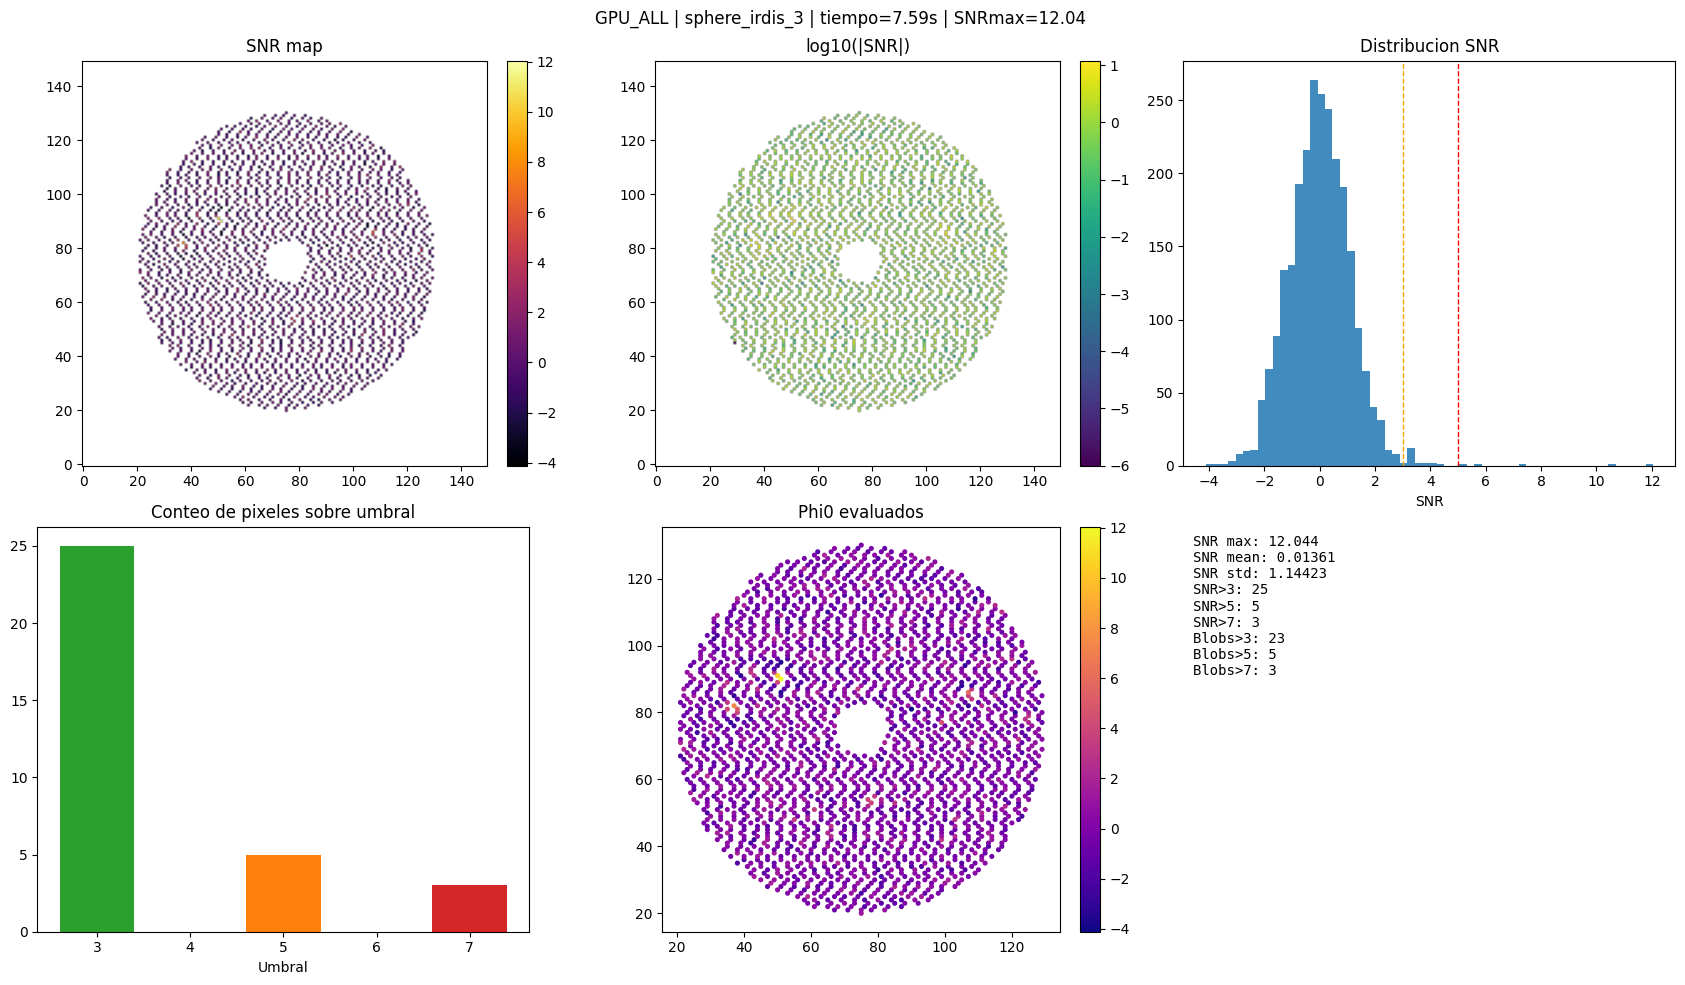

[OK] Figura guardada: /content/drive/MyDrive/paco_benchmarks/gpu_all/fig_gpu_all_sphere_irdis_3.png


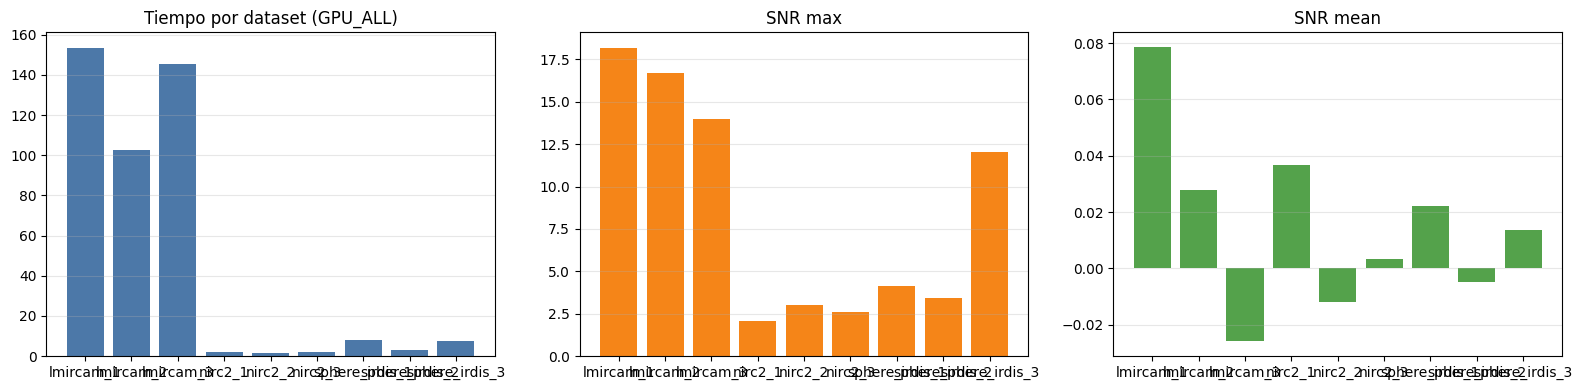

[OK] Figura resumen guardada: /content/drive/MyDrive/paco_benchmarks/gpu_all/summary_gpu_all.png


In [7]:
# Visualizaciones y estadisticas cientificas
for ds_name, res in results_by_dataset.items():
    snr = np.asarray(res["snr"])
    snr_map = np.asarray(res["snr_map"])
    phi0s = np.asarray(res["phi0s"])

    fig, axes = plt.subplots(2, 3, figsize=(17, 10))
    fig.suptitle(f"{RUN_LABEL.upper()} | {ds_name} | tiempo={res['time_s']:.2f}s | SNRmax={res['snr_max']:.2f}")

    # SNR map
    im0 = axes[0, 0].imshow(snr_map, origin="lower", cmap="inferno")
    axes[0, 0].set_title("SNR map")
    plt.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04)

    # SNR map log
    safe = np.where(np.isfinite(snr_map), np.abs(snr_map), np.nan)
    im1 = axes[0, 1].imshow(np.log10(safe + 1e-6), origin="lower", cmap="viridis")
    axes[0, 1].set_title("log10(|SNR|)")
    plt.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

    # Histograma
    axes[0, 2].hist(snr, bins=60, color="#1f77b4", alpha=0.85)
    axes[0, 2].axvline(3, color="orange", ls="--", lw=1)
    axes[0, 2].axvline(5, color="red", ls="--", lw=1)
    axes[0, 2].set_title("Distribucion SNR")
    axes[0, 2].set_xlabel("SNR")

    # Detecciones por umbral
    x = [3, 5, 7]
    y = [res["count_snr_gt_3"], res["count_snr_gt_5"], res["count_snr_gt_7"]]
    axes[1, 0].bar(x, y, color=["#2ca02c", "#ff7f0e", "#d62728"])
    axes[1, 0].set_title("Conteo de pixeles sobre umbral")
    axes[1, 0].set_xlabel("Umbral")

    # Scatter phi0s coloreado por SNR
    sc = axes[1, 1].scatter(phi0s[:, 0], phi0s[:, 1], c=snr, s=7, cmap="plasma")
    axes[1, 1].set_title("Phi0 evaluados")
    axes[1, 1].set_aspect("equal")
    plt.colorbar(sc, ax=axes[1, 1], fraction=0.046, pad=0.04)

    # Texto estadistico
    axes[1, 2].axis("off")
    txt = (
        f"SNR max: {res['snr_max']:.3f}\n"
        f"SNR mean: {res['snr_mean']:.5f}\n"
        f"SNR std: {res['snr_std']:.5f}\n"
        f"SNR>3: {res['count_snr_gt_3']}\n"
        f"SNR>5: {res['count_snr_gt_5']}\n"
        f"SNR>7: {res['count_snr_gt_7']}\n"
        f"Blobs>3: {res['detections'][3]['count']}\n"
        f"Blobs>5: {res['detections'][5]['count']}\n"
        f"Blobs>7: {res['detections'][7]['count']}\n"
    )
    axes[1, 2].text(0.02, 0.98, txt, va="top", family="monospace")

    plt.tight_layout()
    fig_path = OUTPUT_DIR / f"fig_{RUN_LABEL}_{ds_name}.png"
    plt.savefig(fig_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"[OK] Figura guardada: {fig_path}")

# Comparativa entre datasets dentro del mismo backend
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].bar(benchmark_df["Dataset"], benchmark_df["Tiempo (s)"], color="#4c78a8")
axes[0].set_title(f"Tiempo por dataset ({RUN_LABEL.upper()})")
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(benchmark_df["Dataset"], benchmark_df["SNR max"], color="#f58518")
axes[1].set_title("SNR max")
axes[1].grid(axis="y", alpha=0.3)

axes[2].bar(benchmark_df["Dataset"], benchmark_df["SNR mean"], color="#54a24b")
axes[2].set_title("SNR mean")
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
summary_fig = OUTPUT_DIR / f"summary_{RUN_LABEL}.png"
plt.savefig(summary_fig, dpi=120, bbox_inches="tight")
plt.show()
print(f"[OK] Figura resumen guardada: {summary_fig}")

In [8]:
# Exportar artefactos + comparacion con notebook contraparte (si existe)
benchmark_csv = OUTPUT_DIR / f"benchmark_results_{RUN_LABEL}.csv"
validation_csv = OUTPUT_DIR / f"validation_{RUN_LABEL}.csv"
profile_csv = OUTPUT_DIR / f"profile_{RUN_LABEL}.csv"
meta_json = OUTPUT_DIR / f"metadata_{RUN_LABEL}.json"

benchmark_df.to_csv(benchmark_csv, index=False)
validation_df.to_csv(validation_csv, index=False)
if "profile_df" in globals() and isinstance(profile_df, pd.DataFrame):
    profile_df.to_csv(profile_csv, index=False)

extra_metrics_csv = OUTPUT_DIR / f"extra_metrics_{RUN_LABEL}.csv"
instrument_metrics_csv = OUTPUT_DIR / f"instrument_metrics_{RUN_LABEL}.csv"
global_metrics_csv = OUTPUT_DIR / f"global_metrics_{RUN_LABEL}.csv"
if "extra_metrics_df" in globals() and isinstance(extra_metrics_df, pd.DataFrame):
    extra_metrics_df.to_csv(extra_metrics_csv, index=False)
if "instrument_metrics_df" in globals() and isinstance(instrument_metrics_df, pd.DataFrame):
    instrument_metrics_df.to_csv(instrument_metrics_csv, index=False)
if "global_metrics_df" in globals() and isinstance(global_metrics_df, pd.DataFrame):
    global_metrics_df.to_csv(global_metrics_csv, index=False)

meta = {
    "run_label": RUN_LABEL,
    "enable_gpu": ENABLE_GPU,
    "gpu_available": GPU_AVAILABLE,
    "gpu_name": GPU_NAME,
    "vip_version": getattr(vip, "__version__", "desconocida"),
    "timestamp": datetime.utcnow().isoformat() + "Z",
    "hp_fingerprint": HP_FINGERPRINT,
    "locked_hparams": LOCKED_HPARAMS,
    "extra_metrics_files": {
        "extra_metrics_csv": str(extra_metrics_csv) if extra_metrics_csv.exists() else None,
        "instrument_metrics_csv": str(instrument_metrics_csv) if instrument_metrics_csv.exists() else None,
        "global_metrics_csv": str(global_metrics_csv) if global_metrics_csv.exists() else None,
    },
}
with open(meta_json, "w") as f:
    json.dump(meta, f, indent=2)

print(f"[OK] Exportado: {benchmark_csv}")
print(f"[OK] Exportado: {validation_csv}")
print(f"[OK] Exportado: {profile_csv if profile_csv.exists() else '(sin profile csv)'}")
print(f"[OK] Exportado: {extra_metrics_csv if extra_metrics_csv.exists() else '(sin extra metrics csv)'}")
print(f"[OK] Exportado: {instrument_metrics_csv if instrument_metrics_csv.exists() else '(sin instrument metrics csv)'}")
print(f"[OK] Exportado: {global_metrics_csv if global_metrics_csv.exists() else '(sin global metrics csv)'}")
print(f"[OK] Exportado: {meta_json}")

# Comparacion cruzada CPU/GPU si existe la otra corrida
counterpart_dir = DRIVE_ROOT / "paco_benchmarks" / COUNTERPART_LABEL
counterpart_csv = counterpart_dir / f"benchmark_results_{COUNTERPART_LABEL}.csv"
counterpart_meta = counterpart_dir / f"metadata_{COUNTERPART_LABEL}.json"

if counterpart_csv.exists() and counterpart_meta.exists():
    other_df = pd.read_csv(counterpart_csv)
    with open(counterpart_meta) as f:
        other_meta = json.load(f)

    print("\n[INFO] Encontrada corrida contraparte, generando tabla comparativa...")
    print(f"HP actual      : {HP_FINGERPRINT[:16]}")
    print(f"HP contraparte : {other_meta.get('hp_fingerprint', '')[:16]}")

    if other_meta.get("hp_fingerprint") != HP_FINGERPRINT:
        print("[WARNING] Fingerprint de hiperparametros no coincide. Comparacion no 1:1.")

    merged = benchmark_df.merge(
        other_df,
        on="Dataset",
        suffixes=(f"_{RUN_LABEL}", f"_{COUNTERPART_LABEL}"),
    )

    # Resolver etiquetas reales para columnas CPU/GPU
    labels = [RUN_LABEL, COUNTERPART_LABEL]
    cpu_label = next((lb for lb in labels if "cpu" in lb), None)
    gpu_label = next((lb for lb in labels if "gpu" in lb), None)

    if cpu_label is None or gpu_label is None:
        print("[WARNING] No se pudo inferir etiqueta CPU/GPU en nombres de corrida.")
    else:
        def _col(base, label):
            return f"{base}_{label}"

        merged["Speedup CPU/GPU"] = merged[_col("Tiempo (s)", cpu_label)] / merged[_col("Tiempo (s)", gpu_label)]
        merged["Delta SNR max (GPU-CPU)"] = merged[_col("SNR max", gpu_label)] - merged[_col("SNR max", cpu_label)]
        merged["Delta SNR mean (GPU-CPU)"] = merged[_col("SNR mean", gpu_label)] - merged[_col("SNR mean", cpu_label)]

        view = pd.DataFrame({
            "Dataset": merged["Dataset"],
            "Tiempo (s)_cpu": merged[_col("Tiempo (s)", cpu_label)],
            "Tiempo (s)_gpu": merged[_col("Tiempo (s)", gpu_label)],
            "Speedup CPU/GPU": merged["Speedup CPU/GPU"],
            "SNR max_cpu": merged[_col("SNR max", cpu_label)],
            "SNR max_gpu": merged[_col("SNR max", gpu_label)],
            "Delta SNR max (GPU-CPU)": merged["Delta SNR max (GPU-CPU)"],
            "SNR mean_cpu": merged[_col("SNR mean", cpu_label)],
            "SNR mean_gpu": merged[_col("SNR mean", gpu_label)],
            "Delta SNR mean (GPU-CPU)": merged["Delta SNR mean (GPU-CPU)"],
        })
        display(view)

    compare_csv = OUTPUT_DIR / "comparison_cpu_vs_gpu.csv"
    merged.to_csv(compare_csv, index=False)
    print(f"[OK] Comparacion exportada: {compare_csv}")
else:
    print("\n[INFO] Aun no existe corrida contraparte para comparar CPU vs GPU.")

[OK] Exportado: /content/drive/MyDrive/paco_benchmarks/gpu_all/benchmark_results_gpu_all.csv
[OK] Exportado: /content/drive/MyDrive/paco_benchmarks/gpu_all/validation_gpu_all.csv
[OK] Exportado: /content/drive/MyDrive/paco_benchmarks/gpu_all/profile_gpu_all.csv
[OK] Exportado: /content/drive/MyDrive/paco_benchmarks/gpu_all/metadata_gpu_all.json

[INFO] Encontrada corrida contraparte, generando tabla comparativa...
HP actual      : a8300ca1fa4e3342
HP contraparte : a8300ca1fa4e3342


,Dataset,Tiempo (s)_cpu,Tiempo (s)_gpu,Speedup CPU/GPU,SNR max_cpu,SNR max_gpu,Delta SNR max (GPU-CPU),SNR mean_cpu,SNR mean_gpu,Delta SNR mean (GPU-CPU)
0,lmircam_1,1423.985179,153.548293,9.273859,25.715198,18.183560,-7.531637,0.111142,0.078587,-0.032555
1,lmircam_2,930.977262,102.407917,9.090872,23.651627,16.724239,-6.927388,0.039608,0.028005,-0.011603
2,lmircam_3,1372.157136,145.670178,9.419616,19.788648,13.992628,-5.796020,-0.036681,-0.025937,0.010744
3,nirc2_1,16.074771,2.120595,7.580311,2.904008,2.053452,-0.850556,0.051992,0.036764,-0.015228
4,nirc2_2,18.021885,1.694644,10.634617,4.294977,3.037016,-1.257960,-0.017077,-0.012076,0.005001
5,nirc2_3,17.237013,1.967081,8.762735,3.696830,2.614047,-1.082782,0.004761,0.003367,-0.001394
6,sphere_irdis_1,74.109806,8.026467,9.233179,5.860323,4.143901,-1.716421,0.031135,0.022014,-0.009121
7,sphere_irdis_2,25.706000,2.844208,9.038018,4.867606,3.441927,-1.425679,-0.006804,-0.004812,0.001992
8,sphere_irdis_3,67.389349,7.588221,8.880783,17.032870,12.044043,-4.988827,0.019241,0.013605,-0.005636


[OK] Comparacion exportada: /content/drive/MyDrive/paco_benchmarks/gpu_all/comparison_cpu_vs_gpu.csv
